In [1]:
from acsbm import generation, estimation, utils
from acsbm import models2
from acsbm.examples import run_simulation

from functions import *

import warnings
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
from sklearn.metrics.cluster import normalized_mutual_info_score

import numpy as np

In [2]:
warnings.simplefilter('ignore')

In [3]:
def process_node_iterations_ACSBM2_AA(node_list, iteration, relsize, beta, k, B0, M, link='log', direction=False, d=None, method='K-Means'):
    methods = ["acsbm1", "acsbm3", "acsbm1_aa", "acsbm3_aa"]

    dense_results = []
    degree_results = []
    NMI  = {m: [] for m in methods}
    STD  = {m: [] for m in methods}
    TIME = {m: [] for m in methods}

    progress_bar = tqdm(total=len(node_list) * iteration, desc="Processing")

    for n in node_list:

        n = int(n)
        cluster_sizes = [int(n*r) for r in relsize]
        _, labels = make_labels(n, cluster_sizes)   # zero-based labels
        
        density_list = []
        degree_list = []

        score = {m: [] for m in methods}
        tlist = {m: [] for m in methods}

        for it in range(iteration):

            if k==2:
                B_scaled = B0 + np.log(n**(-0.8))
                model = models.MultiCovariateModel(
                    B = B_scaled,
                    covariates=[
                        models.Covariate.simple(beta[m], k) 
                        for m in range(M)
                    ],
                    link=models.LinkFunction.log()
                )
            elif k==3:
                B_scaled = B0 + np.log(n**(-0.5))
                model = models.MultiCovariateModel(
                    B = B_scaled,
                    covariates=[
                        models.Covariate.simple(beta[m], k) 
                        for m in range(M)
                    ],
                    link=models.LinkFunction.log()
                )

            ndd = models.NodeDataDistribution.uniform_for_model(model)
            net = generation.generate_network_directed(model, ndd, n, directed=direction, random_state=it)
            Adj = net.A.toarray()
            X = net.Z

            # G = nx.from_numpy_matrix(Adj)
            if direction:
                G = nx.from_numpy_array(Adj, create_using=nx.DiGraph)
            else:
                G = nx.from_numpy_array(Adj, create_using=nx.Graph)
            density_list.append(nx.density(G))

            deg = np.sum(Adj, axis = 1)
            degree_list.append(np.mean(deg))
            
            # ACSBM step1/step3
            t0 = time.time()
            ic = estimation.initial_cluster(net, k=model.n_communities, d=len(net.block_sizes), random_state=it)
            tlist["acsbm1"].append(time.time()-t0)
            score["acsbm1"].append(normalized_mutual_info_score(labels, ic.theta_tilde))

            t0 = time.time()
            rc = estimation.reconcile_clusters(net, ic)
            tlist["acsbm3"].append(time.time()-t0)
            score["acsbm3"].append(normalized_mutual_info_score(labels, rc.theta))

            # ACSBM_AA step1/step3
            net_aa = generation.GeneratedNetwork(
                A=Adj, theta=net.theta, Z=net.Z,  Z_tilde=net.Z_tilde, block_sizes=net.block_sizes, model=net.model
            )

            # Step1 on AA
            t0 = time.time()
            ic_aa = estimation.initial_cluster_DA(net_aa, k=model.n_communities, d=len(net_aa.block_sizes), random_state=it)
            tlist["acsbm1_aa"].append(time.time() - t0)
            score["acsbm1_aa"].append(normalized_mutual_info_score(labels, ic_aa.theta_tilde))

            # Step3 on AA
            t0 = time.time()
            rc_aa = estimation.reconcile_clusters(net_aa, ic_aa)
            tlist["acsbm3_aa"].append(time.time() - t0)
            score["acsbm3_aa"].append(normalized_mutual_info_score(labels, rc_aa.theta))

            progress_bar.update(1)

        # ---- aggcore_mate per sparsity ----
        dense_results.append(np.mean(density_list))
        degree_results.append(np.mean(degree_list))
        
        # ---- aggcore_mate per n ----
        for m in methods:
            NMI[m].append(np.mean(score[m]))
            STD[m].append(np.std(score[m]))
            TIME[m].append(np.mean(tlist[m]))

    progress_bar.close()
    print("Processing completed.")

    # ---- keep your original return order ----
    return (
        dense_results,
        NMI["acsbm1"], NMI["acsbm3"], NMI["acsbm1_aa"], NMI["acsbm3_aa"],
        STD["acsbm1"], STD["acsbm3"], STD["acsbm1_aa"], STD["acsbm3_aa"],
        TIME["acsbm1"], TIME["acsbm3"], TIME["acsbm1_aa"], TIME["acsbm3_aa"]
    )

# Varying Network Size

## Assortative

### Undirected

#### K=2

In [4]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
node_list = [500, 1000, 1500, 2000, 2500, 3000]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (assortular case)
B0 = np.array([[1.5, 0.5],
              [0.5, 1.5]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_node_iterations_ACSBM2_AA(
    node_list=node_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=False
)

# 7. Results unpack
(
    dense_assort_node,
    
    NMI_ACSBM1_assort_node, NMI_ACSBM3_assort_node, NMI_ACSBM1_AA_assort_node, NMI_ACSBM3_AA_assort_node,
    
    std_ACSBM1_assort_node, std_ACSBM3_assort_node, std_ACSBM1_AA_assort_node, std_ACSBM3_AA_assort_node,
    
    time_ACSBM1_assort_node, time_ACSBM3_assort_node, time_ACSBM1_AA_assort_node, time_ACSBM3_AA_assort_node
    
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


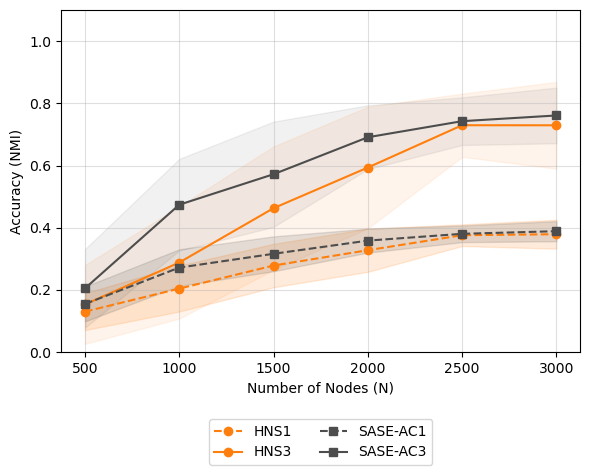

In [5]:
import numpy as np
import matplotlib.pyplot as plt

node_list = [500, 1000, 1500, 2000, 2500, 3000]

plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_assort_node, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_assort_node) - np.array(std_ACSBM1_assort_node),
                 np.array(NMI_ACSBM1_assort_node) + np.array(std_ACSBM1_assort_node),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_assort_node, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_assort_node) - np.array(std_ACSBM3_assort_node),
                 np.array(NMI_ACSBM3_assort_node) + np.array(std_ACSBM3_assort_node),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_AA_assort_node, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_AA_assort_node) - np.array(std_ACSBM1_AA_assort_node),
                 np.array(NMI_ACSBM1_AA_assort_node) + np.array(std_ACSBM1_AA_assort_node),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_AA_assort_node, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_AA_assort_node) - np.array(std_ACSBM3_AA_assort_node),
                 np.array(NMI_ACSBM3_AA_assort_node) + np.array(std_ACSBM3_AA_assort_node),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Number of Nodes (N)')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

### Directed

#### K=2

In [6]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
node_list = [500, 1000, 1500, 2000, 2500, 3000]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (assortular case)
B0 = np.array([[1.5, 0.5],
              [0.5, 1.5]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_node_iterations_ACSBM2_AA(
    node_list=node_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=True
)

# 7. Results unpack
(
    dense_assort_dir_node,
    
    NMI_ACSBM1_assort_dir_node, NMI_ACSBM3_assort_dir_node, NMI_ACSBM1_AA_assort_dir_node, NMI_ACSBM3_AA_assort_dir_node,
    
    std_ACSBM1_assort_dir_node, std_ACSBM3_assort_dir_node, std_ACSBM1_AA_assort_dir_node, std_ACSBM3_AA_assort_dir_node,
    
    time_ACSBM1_assort_dir_node, time_ACSBM3_assort_dir_node, time_ACSBM1_AA_assort_dir_node, time_ACSBM3_AA_assort_dir_node
    
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


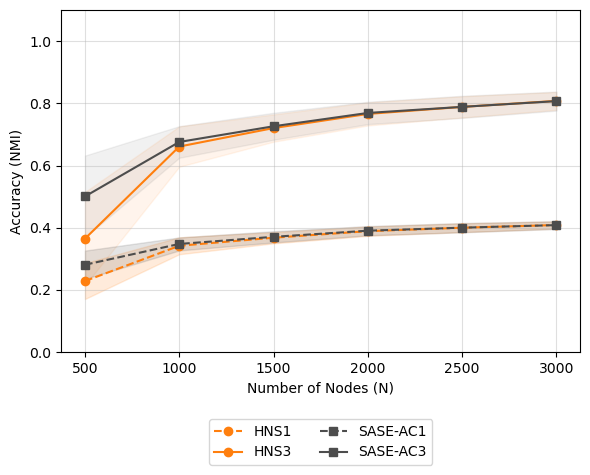

In [7]:
import numpy as np
import matplotlib.pyplot as plt

node_list = [500, 1000, 1500, 2000, 2500, 3000] 

plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_assort_dir_node, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_assort_dir_node) - np.array(std_ACSBM1_assort_dir_node),
                 np.array(NMI_ACSBM1_assort_dir_node) + np.array(std_ACSBM1_assort_dir_node),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_assort_dir_node, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_assort_dir_node) - np.array(std_ACSBM3_assort_dir_node),
                 np.array(NMI_ACSBM3_assort_dir_node) + np.array(std_ACSBM3_assort_dir_node),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_AA_assort_dir_node, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_AA_assort_dir_node) - np.array(std_ACSBM1_AA_assort_dir_node),
                 np.array(NMI_ACSBM1_AA_assort_dir_node) + np.array(std_ACSBM1_AA_assort_dir_node),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_AA_assort_dir_node, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_AA_assort_dir_node) - np.array(std_ACSBM3_AA_assort_dir_node),
                 np.array(NMI_ACSBM3_AA_assort_dir_node) + np.array(std_ACSBM3_AA_assort_dir_node),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Number of Nodes (N)')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

## Non-assortative

### Undirected

#### K=2

In [8]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
node_list = [500, 1000, 1500, 2000, 2500, 3000]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (regular case)
B0 = np.array([[0.5, 1.5],
               [1.5, 0.5]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_node_iterations_ACSBM2_AA(
    node_list=node_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=False
)

# 7. Results unpack
(
    dense_reg_node,
    
    NMI_ACSBM1_reg_node, NMI_ACSBM3_reg_node, NMI_ACSBM1_AA_reg_node, NMI_ACSBM3_AA_reg_node,
    
    std_ACSBM1_reg_node, std_ACSBM3_reg_node, std_ACSBM1_AA_reg_node, std_ACSBM3_AA_reg_node,
    
    time_ACSBM1_reg_node, time_ACSBM3_reg_node, time_ACSBM1_AA_reg_node, time_ACSBM3_AA_reg_node
    
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


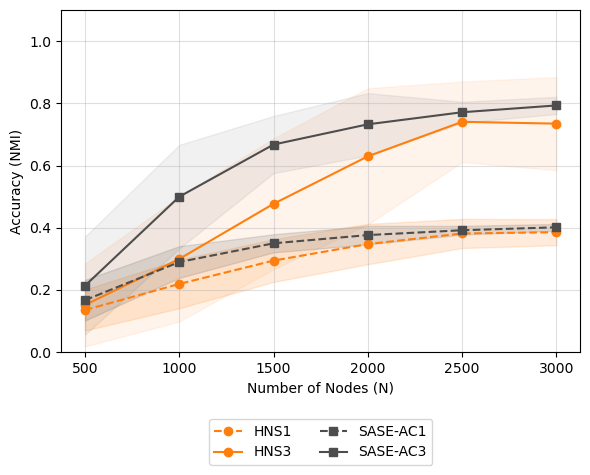

In [9]:
import numpy as np
import matplotlib.pyplot as plt

node_list = [500, 1000, 1500, 2000, 2500, 3000]

plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_reg_node, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_reg_node) - np.array(std_ACSBM1_reg_node),
                 np.array(NMI_ACSBM1_reg_node) + np.array(std_ACSBM1_reg_node),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_reg_node, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_reg_node) - np.array(std_ACSBM3_reg_node),
                 np.array(NMI_ACSBM3_reg_node) + np.array(std_ACSBM3_reg_node),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_AA_reg_node, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_AA_reg_node) - np.array(std_ACSBM1_AA_reg_node),
                 np.array(NMI_ACSBM1_AA_reg_node) + np.array(std_ACSBM1_AA_reg_node),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_AA_reg_node, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_AA_reg_node) - np.array(std_ACSBM3_AA_reg_node),
                 np.array(NMI_ACSBM3_AA_reg_node) + np.array(std_ACSBM3_AA_reg_node),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Number of Nodes (N)')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

### Directed

#### K=2

In [10]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
node_list = [500, 1000, 1500, 2000, 2500, 3000]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (reg_dirular case)
B0 = np.array([[0.5, 1.5],
               [1.5, 0.5]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_node_iterations_ACSBM2_AA(
    node_list=node_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=True
)

# 7. Results unpack
(
    dense_reg_dir_node,
    
    NMI_ACSBM1_reg_dir_node, NMI_ACSBM3_reg_dir_node, NMI_ACSBM1_AA_reg_dir_node, NMI_ACSBM3_AA_reg_dir_node,
    
    std_ACSBM1_reg_dir_node, std_ACSBM3_reg_dir_node, std_ACSBM1_AA_reg_dir_node, std_ACSBM3_AA_reg_dir_node,
    
    time_ACSBM1_reg_dir_node, time_ACSBM3_reg_dir_node, time_ACSBM1_AA_reg_dir_node, time_ACSBM3_AA_reg_dir_node
    
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


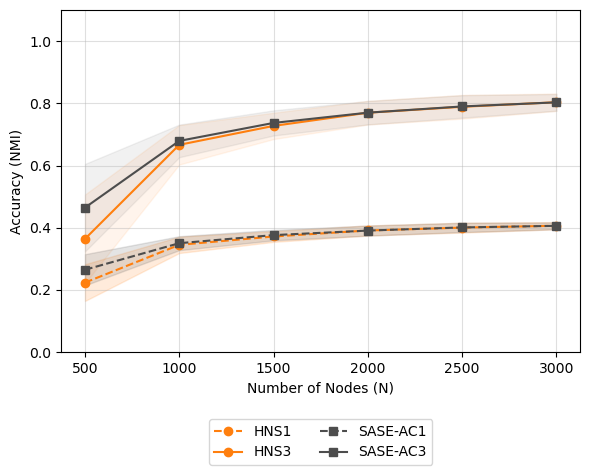

In [11]:
import numpy as np
import matplotlib.pyplot as plt

node_list = [500, 1000, 1500, 2000, 2500, 3000]

plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_reg_dir_node, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_reg_dir_node) - np.array(std_ACSBM1_reg_dir_node),
                 np.array(NMI_ACSBM1_reg_dir_node) + np.array(std_ACSBM1_reg_dir_node),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_reg_dir_node, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_reg_dir_node) - np.array(std_ACSBM3_reg_dir_node),
                 np.array(NMI_ACSBM3_reg_dir_node) + np.array(std_ACSBM3_reg_dir_node),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_AA_reg_dir_node, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_AA_reg_dir_node) - np.array(std_ACSBM1_AA_reg_dir_node),
                 np.array(NMI_ACSBM1_AA_reg_dir_node) + np.array(std_ACSBM1_AA_reg_dir_node),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_AA_reg_dir_node, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_AA_reg_dir_node) - np.array(std_ACSBM3_AA_reg_dir_node),
                 np.array(NMI_ACSBM3_AA_reg_dir_node) + np.array(std_ACSBM3_AA_reg_dir_node),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Number of Nodes (N)')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

## Core-periphery

### Undirected

#### K=2

In [12]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
node_list = [500, 1000, 1500, 2000, 2500, 3000]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (irregular case)
B0 = np.array([[2, 1],
              [1, 0.8]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_node_iterations_ACSBM2_AA(
    node_list=node_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=False
)

# 7. Results unpack
(
    dense_irreg_node,
    
    NMI_ACSBM1_irreg_node, NMI_ACSBM3_irreg_node, NMI_ACSBM1_AA_irreg_node, NMI_ACSBM3_AA_irreg_node,
    
    std_ACSBM1_irreg_node, std_ACSBM3_irreg_node, std_ACSBM1_AA_irreg_node, std_ACSBM3_AA_irreg_node,
    
    time_ACSBM1_irreg_node, time_ACSBM3_irreg_node, time_ACSBM1_AA_irreg_node, time_ACSBM3_AA_irreg_node
    
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


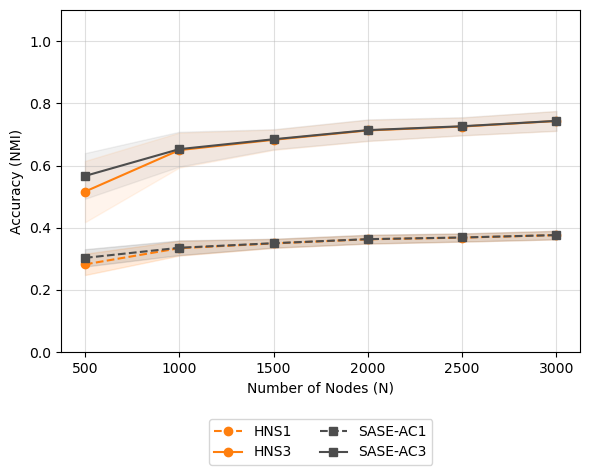

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
node_list = [500, 1000, 1500, 2000, 2500, 3000]

# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_irreg_node, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_irreg_node) - np.array(std_ACSBM1_irreg_node),
                 np.array(NMI_ACSBM1_irreg_node) + np.array(std_ACSBM1_irreg_node),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_irreg_node, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_irreg_node) - np.array(std_ACSBM3_irreg_node),
                 np.array(NMI_ACSBM3_irreg_node) + np.array(std_ACSBM3_irreg_node),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_AA_irreg_node, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_AA_irreg_node) - np.array(std_ACSBM1_AA_irreg_node),
                 np.array(NMI_ACSBM1_AA_irreg_node) + np.array(std_ACSBM1_AA_irreg_node),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_AA_irreg_node, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_AA_irreg_node) - np.array(std_ACSBM3_AA_irreg_node),
                 np.array(NMI_ACSBM3_AA_irreg_node) + np.array(std_ACSBM3_AA_irreg_node),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Number of Nodes (N)')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

### Directed

#### K=2

In [14]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
node_list = [500, 1000, 1500, 2000, 2500, 3000]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (irreg_dirular case)
B0 = np.array([[2, 1],
              [1, 0.8]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_node_iterations_ACSBM2_AA(
    node_list=node_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=True
)

# 7. Results unpack
(
    dense_irreg_dir_node,
    
    NMI_ACSBM1_irreg_dir_node, NMI_ACSBM3_irreg_dir_node, NMI_ACSBM1_AA_irreg_dir_node, NMI_ACSBM3_AA_irreg_dir_node,
    
    std_ACSBM1_irreg_dir_node, std_ACSBM3_irreg_dir_node, std_ACSBM1_AA_irreg_dir_node, std_ACSBM3_AA_irreg_dir_node,
    
    time_ACSBM1_irreg_dir_node, time_ACSBM3_irreg_dir_node, time_ACSBM1_AA_irreg_dir_node, time_ACSBM3_AA_irreg_dir_node
    
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


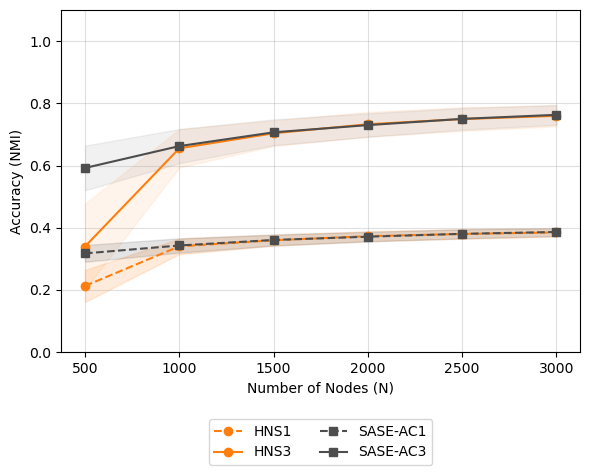

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
node_list = [500, 1000, 1500, 2000, 2500, 3000]

# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_irreg_dir_node, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_irreg_dir_node) - np.array(std_ACSBM1_irreg_dir_node),
                 np.array(NMI_ACSBM1_irreg_dir_node) + np.array(std_ACSBM1_irreg_dir_node),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_irreg_dir_node, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_irreg_dir_node) - np.array(std_ACSBM3_irreg_dir_node),
                 np.array(NMI_ACSBM3_irreg_dir_node) + np.array(std_ACSBM3_irreg_dir_node),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(node_list, NMI_ACSBM1_AA_irreg_dir_node, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM1_AA_irreg_dir_node) - np.array(std_ACSBM1_AA_irreg_dir_node),
                 np.array(NMI_ACSBM1_AA_irreg_dir_node) + np.array(std_ACSBM1_AA_irreg_dir_node),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(node_list, NMI_ACSBM3_AA_irreg_dir_node, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(node_list,
                 np.array(NMI_ACSBM3_AA_irreg_dir_node) - np.array(std_ACSBM3_AA_irreg_dir_node),
                 np.array(NMI_ACSBM3_AA_irreg_dir_node) + np.array(std_ACSBM3_AA_irreg_dir_node),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Number of Nodes (N)')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

# Varying Network Sparsity Parameter

In [16]:
import networkx as nx

def process_alpha_iterations_ACSBM2_AA(n, alpha_list, iteration, relsize, beta, k, B0, M, link='log', direction=False, d=None, method='K-Means'):
    methods = ["acsbm1", "acsbm3", "acsbm1_aa", "acsbm3_aa"]

    dense_results = []
    NMI  = {m: [] for m in methods}
    STD  = {m: [] for m in methods}
    TIME = {m: [] for m in methods}

    
    n = int(n)
    cluster_sizes = [int(n*r) for r in relsize]
    _, labels = make_labels(n, cluster_sizes)   # zero-based labels
    

    progress_bar = tqdm(total=len(alpha_list) * iteration, desc="Processing")

    for a in alpha_list:
        
        density_list = []

        score = {m: [] for m in methods}
        tlist = {m: [] for m in methods}

        for it in range(iteration):

            # 1. Generate adjacency via block + covariates
            # B = np.exp(B) * (n**(-0.8))


            if k==2:
                B_scaled = B0 + np.log(n**(-a))
                # model = models.MultiCovariateModel(
                #     B = B_scaled,
                #     covariates=[
                #         models.Covariate.simple(beta[m], k) 
                #         for m in range(M)
                #     ],
                #     link=models.LinkFunction.logit()
                # )

                model = models.MultiCovariateModel(
                    B=B_scaled,
                    covariates=[
                        models.Covariate.simple(beta[m], k)
                        for m in range(M)
                    ],
                    link=models.LinkFunction.log()
                )
            elif k==3:
                B_scaled = B0 + np.log(n**(-0.5))
                model = models.MultiCovariateModel(
                    B = B_scaled,
                    covariates=[
                        models.Covariate.simple(beta[m], k) 
                        for m in range(M)
                    ],
                    link=models.LinkFunction.log()
                )

            ndd = models.NodeDataDistribution.uniform_for_model(model)
            net = generation.generate_network_directed(model, ndd, n, directed=direction, random_state=it)
            Adj = net.A.toarray()
            X = net.Z

            # G = nx.from_numpy_matrix(Adj)
            G = nx.from_numpy_array(Adj)
            density_list.append(nx.density(G))
            
            # ACSBM step1/step3
            t0 = time.time()
            ic = estimation.initial_cluster(net, k=model.n_communities, d=len(net.block_sizes), random_state=it)
            tlist["acsbm1"].append(time.time()-t0)
            score["acsbm1"].append(normalized_mutual_info_score(labels, ic.theta_tilde))

            t0 = time.time()
            rc = estimation.reconcile_clusters(net, ic)
            tlist["acsbm3"].append(time.time()-t0)
            score["acsbm3"].append(normalized_mutual_info_score(labels, rc.theta))

            # ACSBM_AA step1/step3
            net_aa = generation.GeneratedNetwork(
                A=Adj,
                theta=net.theta,
                Z=net.Z,
                Z_tilde=net.Z_tilde,
                block_sizes=net.block_sizes,
                model=net.model
            )

            # Step1 on AA
            t0 = time.time()
            ic_aa = estimation.initial_cluster_DA(net_aa, k=model.n_communities, d=len(net_aa.block_sizes), random_state=it)
            tlist["acsbm1_aa"].append(time.time() - t0)
            score["acsbm1_aa"].append(normalized_mutual_info_score(labels, ic_aa.theta_tilde))

            # Step3 on AA
            t0 = time.time()
            rc_aa = estimation.reconcile_clusters(net_aa, ic_aa)
            tlist["acsbm3_aa"].append(time.time() - t0)
            score["acsbm3_aa"].append(normalized_mutual_info_score(labels, rc_aa.theta))

            progress_bar.update(1)

        # ---- aggcore_mate per sparsity ----
        dense_results.append(np.mean(density_list))
        
        # ---- aggcore_mate per n ----
        for m in methods:
            NMI[m].append(np.mean(score[m]))
            STD[m].append(np.std(score[m]))
            TIME[m].append(np.mean(tlist[m]))

    progress_bar.close()
    print("Processing completed.")

    # ---- keep your original return order ----
    return (
        dense_results,
        NMI["acsbm1"], NMI["acsbm3"], NMI["acsbm1_aa"], NMI["acsbm3_aa"],
        STD["acsbm1"], STD["acsbm3"], STD["acsbm1_aa"], STD["acsbm3_aa"],
        TIME["acsbm1"], TIME["acsbm3"], TIME["acsbm1_aa"], TIME["acsbm3_aa"]
    )

## Assortative

### Undirected

In [17]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
alpha_list = [0.5, 0.55, 0.6, 0.65, 0.7, 0.8, 0.9]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (assort_dirular case)
B0 = np.array([[1.5, 0.5],
              [0.5, 1.5]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_alpha_iterations_ACSBM2_AA(
    n=1000,
    alpha_list=alpha_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=False
)

# 7. Results unpack
(
    dense_assort_alpha,
    
    NMI_ACSBM1_assort_alpha, NMI_ACSBM3_assort_alpha, NMI_ACSBM1_AA_assort_alpha, NMI_ACSBM3_AA_assort_alpha,
    
    std_ACSBM1_assort_alpha, std_ACSBM3_assort_alpha, std_ACSBM1_AA_assort_alpha, std_ACSBM3_AA_assort_alpha,
    
    time_ACSBM1_assort_alpha, time_ACSBM3_assort_alpha, time_ACSBM1_AA_assort_alpha, time_ACSBM3_AA_assort_alpha
    
) = results

Processing:   0%|          | 0/350 [00:00<?, ?it/s]

Processing completed.


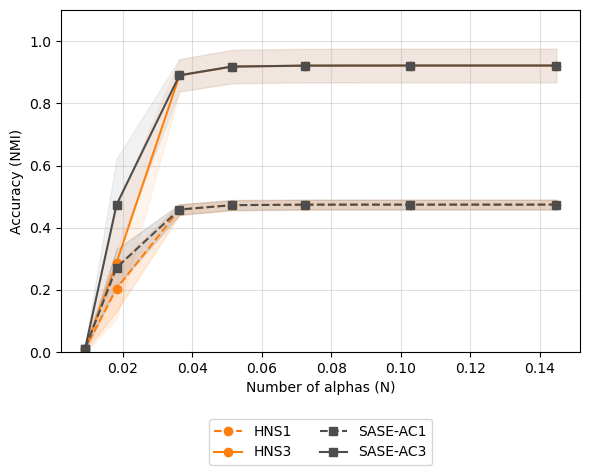

In [18]:
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(dense_assort_alpha, NMI_ACSBM1_assort_alpha, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(dense_assort_alpha,
                 np.array(NMI_ACSBM1_assort_alpha) - np.array(std_ACSBM1_assort_alpha),
                 np.array(NMI_ACSBM1_assort_alpha) + np.array(std_ACSBM1_assort_alpha),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(dense_assort_alpha, NMI_ACSBM3_assort_alpha, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(dense_assort_alpha,
                 np.array(NMI_ACSBM3_assort_alpha) - np.array(std_ACSBM3_assort_alpha),
                 np.array(NMI_ACSBM3_assort_alpha) + np.array(std_ACSBM3_assort_alpha),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(dense_assort_alpha, NMI_ACSBM1_AA_assort_alpha, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(dense_assort_alpha,
                 np.array(NMI_ACSBM1_AA_assort_alpha) - np.array(std_ACSBM1_AA_assort_alpha),
                 np.array(NMI_ACSBM1_AA_assort_alpha) + np.array(std_ACSBM1_AA_assort_alpha),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(dense_assort_alpha, NMI_ACSBM3_AA_assort_alpha, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(dense_assort_alpha,
                 np.array(NMI_ACSBM3_AA_assort_alpha) - np.array(std_ACSBM3_AA_assort_alpha),
                 np.array(NMI_ACSBM3_AA_assort_alpha) + np.array(std_ACSBM3_AA_assort_alpha),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Number of alphas (N)')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

### Directed

In [19]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
alpha_list = [0.5, 0.55, 0.6, 0.65, 0.7, 0.8, 0.9]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (assort_dirular case)
B0 = np.array([[1.5, 0.5],
              [0.5, 1.5]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_alpha_iterations_ACSBM2_AA(
    n=1000,
    alpha_list=alpha_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=True
)

# 7. Results unpack
(
    dense_assort_dir_alpha,
    
    NMI_ACSBM1_assort_dir_alpha, NMI_ACSBM3_assort_dir_alpha, NMI_ACSBM1_AA_assort_dir_alpha, NMI_ACSBM3_AA_assort_dir_alpha,
    
    std_ACSBM1_assort_dir_alpha, std_ACSBM3_assort_dir_alpha, std_ACSBM1_AA_assort_dir_alpha, std_ACSBM3_AA_assort_dir_alpha,
    
    time_ACSBM1_assort_dir_alpha, time_ACSBM3_assort_dir_alpha, time_ACSBM1_AA_assort_dir_alpha, time_ACSBM3_AA_assort_dir_alpha
    
) = results

Processing:   0%|          | 0/350 [00:00<?, ?it/s]

Processing completed.


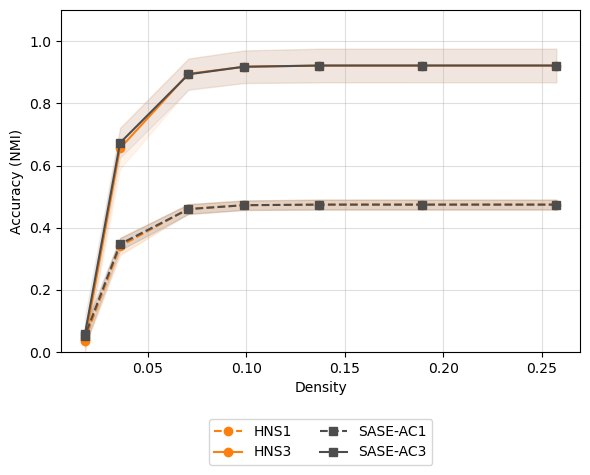

In [20]:
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(dense_assort_dir_alpha, NMI_ACSBM1_assort_dir_alpha, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(dense_assort_dir_alpha,
                 np.array(NMI_ACSBM1_assort_dir_alpha) - np.array(std_ACSBM1_assort_dir_alpha),
                 np.array(NMI_ACSBM1_assort_dir_alpha) + np.array(std_ACSBM1_assort_dir_alpha),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(dense_assort_dir_alpha, NMI_ACSBM3_assort_dir_alpha, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(dense_assort_dir_alpha,
                 np.array(NMI_ACSBM3_assort_dir_alpha) - np.array(std_ACSBM3_assort_dir_alpha),
                 np.array(NMI_ACSBM3_assort_dir_alpha) + np.array(std_ACSBM3_assort_dir_alpha),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(dense_assort_dir_alpha, NMI_ACSBM1_AA_assort_dir_alpha, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(dense_assort_dir_alpha,
                 np.array(NMI_ACSBM1_AA_assort_dir_alpha) - np.array(std_ACSBM1_AA_assort_dir_alpha),
                 np.array(NMI_ACSBM1_AA_assort_dir_alpha) + np.array(std_ACSBM1_AA_assort_dir_alpha),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(dense_assort_dir_alpha, NMI_ACSBM3_AA_assort_dir_alpha, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(dense_assort_dir_alpha,
                 np.array(NMI_ACSBM3_AA_assort_dir_alpha) - np.array(std_ACSBM3_AA_assort_dir_alpha),
                 np.array(NMI_ACSBM3_AA_assort_dir_alpha) + np.array(std_ACSBM3_AA_assort_dir_alpha),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Density')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

## Non-assortative

### Undirected

In [21]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
alpha_list = [0.5, 0.55, 0.6, 0.65, 0.7, 0.8, 0.9]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (regular case)
B0 = np.array([[0.5, 1.5],
              [1.5, 0.5]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_alpha_iterations_ACSBM2_AA(
    n=1000,
    alpha_list=alpha_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=False
)

# 7. Results unpack
(
    dense_reg_alpha,
    
    NMI_ACSBM1_reg_alpha, NMI_ACSBM3_reg_alpha, NMI_ACSBM1_AA_reg_alpha, NMI_ACSBM3_AA_reg_alpha,
    
    std_ACSBM1_reg_alpha, std_ACSBM3_reg_alpha, std_ACSBM1_AA_reg_alpha, std_ACSBM3_AA_reg_alpha,
    
    time_ACSBM1_reg_alpha, time_ACSBM3_reg_alpha, time_ACSBM1_AA_reg_alpha, time_ACSBM3_AA_reg_alpha
    
) = results

Processing:   0%|          | 0/350 [00:00<?, ?it/s]

Processing completed.


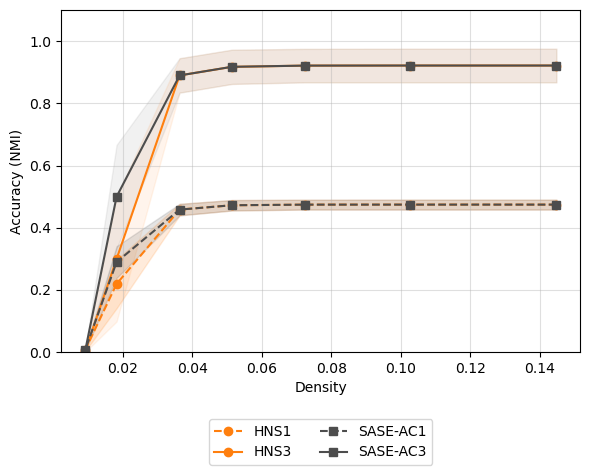

In [22]:
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(dense_reg_alpha, NMI_ACSBM1_reg_alpha, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(dense_reg_alpha,
                 np.array(NMI_ACSBM1_reg_alpha) - np.array(std_ACSBM1_reg_alpha),
                 np.array(NMI_ACSBM1_reg_alpha) + np.array(std_ACSBM1_reg_alpha),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(dense_reg_alpha, NMI_ACSBM3_reg_alpha, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(dense_reg_alpha,
                 np.array(NMI_ACSBM3_reg_alpha) - np.array(std_ACSBM3_reg_alpha),
                 np.array(NMI_ACSBM3_reg_alpha) + np.array(std_ACSBM3_reg_alpha),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(dense_reg_alpha, NMI_ACSBM1_AA_reg_alpha, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(dense_reg_alpha,
                 np.array(NMI_ACSBM1_AA_reg_alpha) - np.array(std_ACSBM1_AA_reg_alpha),
                 np.array(NMI_ACSBM1_AA_reg_alpha) + np.array(std_ACSBM1_AA_reg_alpha),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(dense_reg_alpha, NMI_ACSBM3_AA_reg_alpha, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(dense_reg_alpha,
                 np.array(NMI_ACSBM3_AA_reg_alpha) - np.array(std_ACSBM3_AA_reg_alpha),
                 np.array(NMI_ACSBM3_AA_reg_alpha) + np.array(std_ACSBM3_AA_reg_alpha),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Density')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

### Directed

In [23]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
alpha_list = [0.5, 0.55, 0.6, 0.65, 0.7, 0.8, 0.9]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (reg_dirular case)
B0 = np.array([[0.5, 1.5],
              [1.5, 0.5]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_alpha_iterations_ACSBM2_AA(
    n=1000,
    alpha_list=alpha_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=True
)

# 7. Results unpack
(
    dense_reg_dir_alpha,
    
    NMI_ACSBM1_reg_dir_alpha, NMI_ACSBM3_reg_dir_alpha, NMI_ACSBM1_AA_reg_dir_alpha, NMI_ACSBM3_AA_reg_dir_alpha,
    
    std_ACSBM1_reg_dir_alpha, std_ACSBM3_reg_dir_alpha, std_ACSBM1_AA_reg_dir_alpha, std_ACSBM3_AA_reg_dir_alpha,
    
    time_ACSBM1_reg_dir_alpha, time_ACSBM3_reg_dir_alpha, time_ACSBM1_AA_reg_dir_alpha, time_ACSBM3_AA_reg_dir_alpha
    
) = results

Processing:   0%|          | 0/350 [00:00<?, ?it/s]

Processing completed.


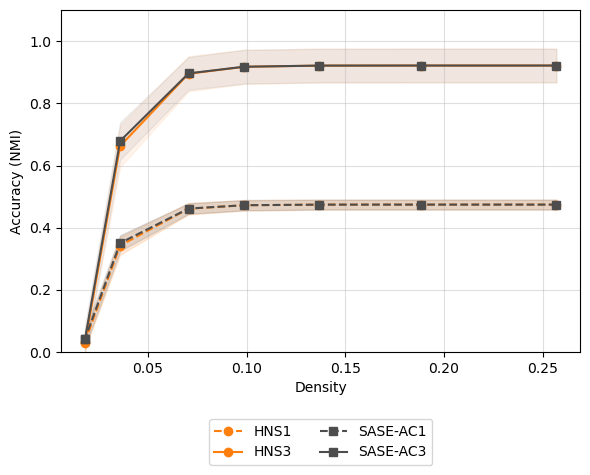

In [24]:
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(dense_reg_dir_alpha, NMI_ACSBM1_reg_dir_alpha, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(dense_reg_dir_alpha,
                 np.array(NMI_ACSBM1_reg_dir_alpha) - np.array(std_ACSBM1_reg_dir_alpha),
                 np.array(NMI_ACSBM1_reg_dir_alpha) + np.array(std_ACSBM1_reg_dir_alpha),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(dense_reg_dir_alpha, NMI_ACSBM3_reg_dir_alpha, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(dense_reg_dir_alpha,
                 np.array(NMI_ACSBM3_reg_dir_alpha) - np.array(std_ACSBM3_reg_dir_alpha),
                 np.array(NMI_ACSBM3_reg_dir_alpha) + np.array(std_ACSBM3_reg_dir_alpha),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(dense_reg_dir_alpha, NMI_ACSBM1_AA_reg_dir_alpha, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(dense_reg_dir_alpha,
                 np.array(NMI_ACSBM1_AA_reg_dir_alpha) - np.array(std_ACSBM1_AA_reg_dir_alpha),
                 np.array(NMI_ACSBM1_AA_reg_dir_alpha) + np.array(std_ACSBM1_AA_reg_dir_alpha),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(dense_reg_dir_alpha, NMI_ACSBM3_AA_reg_dir_alpha, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(dense_reg_dir_alpha,
                 np.array(NMI_ACSBM3_AA_reg_dir_alpha) - np.array(std_ACSBM3_AA_reg_dir_alpha),
                 np.array(NMI_ACSBM3_AA_reg_dir_alpha) + np.array(std_ACSBM3_AA_reg_dir_alpha),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Density')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

## Core-periphery

### Undirected

In [25]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
alpha_list = [0.5, 0.55, 0.6, 0.65, 0.7, 0.8, 0.9]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (irregular case)
B0 = np.array([[2, 1],
              [1, 0.8]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_alpha_iterations_ACSBM2_AA(
    n=1000,
    alpha_list=alpha_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=False
)

# 7. Results unpack
(
    dense_irreg_alpha,
    
    NMI_ACSBM1_irreg_alpha, NMI_ACSBM3_irreg_alpha, NMI_ACSBM1_AA_irreg_alpha, NMI_ACSBM3_AA_irreg_alpha,
    
    std_ACSBM1_irreg_alpha, std_ACSBM3_irreg_alpha, std_ACSBM1_AA_irreg_alpha, std_ACSBM3_AA_irreg_alpha,
    
    time_ACSBM1_irreg_alpha, time_ACSBM3_irreg_alpha, time_ACSBM1_AA_irreg_alpha, time_ACSBM3_AA_irreg_alpha
    
) = results

Processing:   0%|          | 0/350 [00:00<?, ?it/s]

Processing completed.


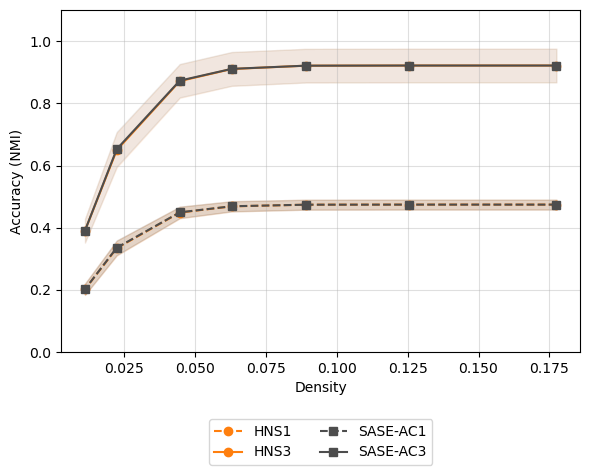

In [26]:
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(dense_irreg_alpha, NMI_ACSBM1_irreg_alpha, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(dense_irreg_alpha,
                 np.array(NMI_ACSBM1_irreg_alpha) - np.array(std_ACSBM1_irreg_alpha),
                 np.array(NMI_ACSBM1_irreg_alpha) + np.array(std_ACSBM1_irreg_alpha),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(dense_irreg_alpha, NMI_ACSBM3_irreg_alpha, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(dense_irreg_alpha,
                 np.array(NMI_ACSBM3_irreg_alpha) - np.array(std_ACSBM3_irreg_alpha),
                 np.array(NMI_ACSBM3_irreg_alpha) + np.array(std_ACSBM3_irreg_alpha),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(dense_irreg_alpha, NMI_ACSBM1_AA_irreg_alpha, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(dense_irreg_alpha,
                 np.array(NMI_ACSBM1_AA_irreg_alpha) - np.array(std_ACSBM1_AA_irreg_alpha),
                 np.array(NMI_ACSBM1_AA_irreg_alpha) + np.array(std_ACSBM1_AA_irreg_alpha),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(dense_irreg_alpha, NMI_ACSBM3_AA_irreg_alpha, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(dense_irreg_alpha,
                 np.array(NMI_ACSBM3_AA_irreg_alpha) - np.array(std_ACSBM3_AA_irreg_alpha),
                 np.array(NMI_ACSBM3_AA_irreg_alpha) + np.array(std_ACSBM3_AA_irreg_alpha),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Density')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

### Directed

In [27]:
from scipy.special import expit

# -----------------------------------
# Dense network case (Definition 2)
# -----------------------------------

# 1. settings
alpha_list = [0.5, 0.55, 0.6, 0.65, 0.7, 0.8, 0.9]   # 논문 dense case range
iteration = 50

# 2. community sizes
relsize = [0.5, 0.5]
k = len(relsize)

# 3. baseline matrix B₀ 설정 (irreg_dirular case)
B0 = np.array([[2, 1],
              [1, 0.8]])

# 4. covariate parameter (β)
beta = [1, -0.5]


# 5. Simulation

results = process_alpha_iterations_ACSBM2_AA(
    n=1000,
    alpha_list=alpha_list,
    iteration=iteration,
    relsize=relsize,
    beta=beta,
    k=k,
    B0=B0,
    M=2,
    direction=True
)

# 7. Results unpack
(
    dense_irreg_dir_alpha,
    
    NMI_ACSBM1_irreg_dir_alpha, NMI_ACSBM3_irreg_dir_alpha, NMI_ACSBM1_AA_irreg_dir_alpha, NMI_ACSBM3_AA_irreg_dir_alpha,
    
    std_ACSBM1_irreg_dir_alpha, std_ACSBM3_irreg_dir_alpha, std_ACSBM1_AA_irreg_dir_alpha, std_ACSBM3_AA_irreg_dir_alpha,
    
    time_ACSBM1_irreg_dir_alpha, time_ACSBM3_irreg_dir_alpha, time_ACSBM1_AA_irreg_dir_alpha, time_ACSBM3_AA_irreg_dir_alpha
    
) = results

Processing:   0%|          | 0/350 [00:00<?, ?it/s]

Processing completed.


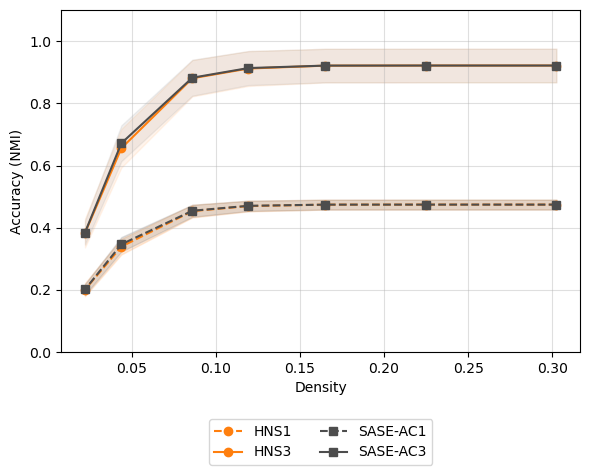

In [28]:
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 5))


# --- ACSBM1 ---
plt.plot(dense_irreg_dir_alpha, NMI_ACSBM1_irreg_dir_alpha, label='HNS1',
         marker='o', color='#ff7f0e', linestyle='dashed')
plt.fill_between(dense_irreg_dir_alpha,
                 np.array(NMI_ACSBM1_irreg_dir_alpha) - np.array(std_ACSBM1_irreg_dir_alpha),
                 np.array(NMI_ACSBM1_irreg_dir_alpha) + np.array(std_ACSBM1_irreg_dir_alpha),
                 alpha=0.15, color='#ff7f0e')

# --- ACSBM3 ---
plt.plot(dense_irreg_dir_alpha, NMI_ACSBM3_irreg_dir_alpha, label='HNS3',
         marker='o', color='#ff7f0e')
plt.fill_between(dense_irreg_dir_alpha,
                 np.array(NMI_ACSBM3_irreg_dir_alpha) - np.array(std_ACSBM3_irreg_dir_alpha),
                 np.array(NMI_ACSBM3_irreg_dir_alpha) + np.array(std_ACSBM3_irreg_dir_alpha),
                 alpha=0.08, color='#ff7f0e')


# --- ACSBM1 ---
plt.plot(dense_irreg_dir_alpha, NMI_ACSBM1_AA_irreg_dir_alpha, label='SASE-AC1',
         marker='s', color='#4d4d4d', linestyle='dashed')
plt.fill_between(dense_irreg_dir_alpha,
                 np.array(NMI_ACSBM1_AA_irreg_dir_alpha) - np.array(std_ACSBM1_AA_irreg_dir_alpha),
                 np.array(NMI_ACSBM1_AA_irreg_dir_alpha) + np.array(std_ACSBM1_AA_irreg_dir_alpha),
                 alpha=0.15, color='#4d4d4d')

# --- ACSBM3 ---
plt.plot(dense_irreg_dir_alpha, NMI_ACSBM3_AA_irreg_dir_alpha, label='SASE-AC3',
         marker='s', color='#4d4d4d')
plt.fill_between(dense_irreg_dir_alpha,
                 np.array(NMI_ACSBM3_AA_irreg_dir_alpha) - np.array(std_ACSBM3_AA_irreg_dir_alpha),
                 np.array(NMI_ACSBM3_AA_irreg_dir_alpha) + np.array(std_ACSBM3_AA_irreg_dir_alpha),
                 alpha=0.08, color='#4d4d4d')



plt.xlabel('Density')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

# Varing covairate effects

In [29]:
from collections import defaultdict
from scipy.stats import bernoulli
import examples


def run_simulation(beta_list, n, iteration, B, direction=False, method='K-Means', k=2):
    
    methods = ["sc", "dsc", "ase", "SASE", "acsbm1", "acsbm3", "acsbm1_aa", "acsbm3_aa"]

    dense_results = []
    NMI  = {m: [] for m in methods}
    STD  = {m: [] for m in methods}
    TIME = {m: [] for m in methods}

    progress_bar = tqdm(total=len(beta_list) * iteration, desc="Processing")

    for beta in beta_list:
        
        density_list = []

        score = {m: [] for m in methods}
        tlist = {m: [] for m in methods}

        for it in range(iteration):

            # Table 1 ACSBM model
            model = models.MultiCovariateModel(
                B=B,
                covariates=[
                    models.Covariate.simple(beta, 3)
                ],
                link=models.LinkFunction.identity()
            )

            # Table 1 joint distribution of (theta, Z)
            ndd = models.NodeDataDistribution(
                np.array([
                    [0.3, 0.1, 0.1],
                    [0.1, 0.1, 0.3]
                ])
            )

            # Generate network
            net = generation.generate_network_directed(model, ndd, n, directed=direction, random_state=it)

            labels = net.theta

            Adj = net.A.toarray()
            X = net.Z

            G = nx.from_numpy_array(Adj)
            density_list.append(nx.density(G))
            
            # ACSBM step1/step3
            t0 = time.time()
            ic = estimation.initial_cluster(net, k=model.n_communities, d=len(net.block_sizes), random_state=it)
            tlist["acsbm1"].append(time.time()-t0)
            score["acsbm1"].append(normalized_mutual_info_score(labels, ic.theta_tilde))

            t0 = time.time()
            rc = estimation.reconcile_clusters(net, ic)
            tlist["acsbm3"].append(time.time()-t0)
            score["acsbm3"].append(normalized_mutual_info_score(labels, rc.theta))

            # ACSBM_AA step1/step3
            net_aa = generation.GeneratedNetwork(
                A=Adj,
                theta=net.theta,
                Z=net.Z,
                Z_tilde=net.Z_tilde,
                block_sizes=net.block_sizes,
                model=net.model
            )

            # Step1 on AA
            t0 = time.time()
            ic_aa = estimation.initial_cluster_DA(net_aa, k=model.n_communities, d=len(net_aa.block_sizes), random_state=it)
            tlist["acsbm1_aa"].append(time.time() - t0)
            score["acsbm1_aa"].append(normalized_mutual_info_score(labels, ic_aa.theta_tilde))

            # Step3 on AA
            t0 = time.time()
            rc_aa = estimation.reconcile_clusters(net_aa, ic_aa)
            tlist["acsbm3_aa"].append(time.time() - t0)
            score["acsbm3_aa"].append(normalized_mutual_info_score(labels, rc_aa.theta))

            progress_bar.update(1)

        # ---- aggcore_mate per sparsity ----
        dense_results.append(np.mean(density_list))
        
        # ---- aggcore_mate per n ----
        for m in methods:
            NMI[m].append(np.mean(score[m]))
            STD[m].append(np.std(score[m]))
            TIME[m].append(np.mean(tlist[m]))

    progress_bar.close()
    print("Processing completed.")

    # ---- keep your original return order ----
    return (
        dense_results,
        NMI["acsbm1"], NMI["acsbm3"], NMI["acsbm1_aa"], NMI["acsbm3_aa"],
        
        STD["acsbm1"], STD["acsbm3"], STD["acsbm1_aa"], STD["acsbm3_aa"],
        
        TIME["acsbm1"], TIME["acsbm3"], TIME["acsbm1_aa"], TIME["acsbm3_aa"]
    )

## Assortative

### Undirected

In [30]:
beta_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
iteration = 50
n = 400

B = 0.3 * np.eye(2) + 0.05

results = run_simulation(
    beta_list=beta_list,
    n=n,
    iteration=iteration,
    B=B
)

(
    dense_beta,

    NMI_ACSBM1_beta, NMI_ACSBM3_beta, NMI_ACSBM1_AA_beta, NMI_ACSBM3_AA_beta,

    std_ACSBM1_beta, std_ACSBM3_beta, std_ACSBM1_AA_beta, std_ACSBM3_AA_beta,

    time_ACSBM1_beta, time_ACSBM3_beta, time_ACSBM1_AA_beta, time_ACSBM3_AA_beta
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


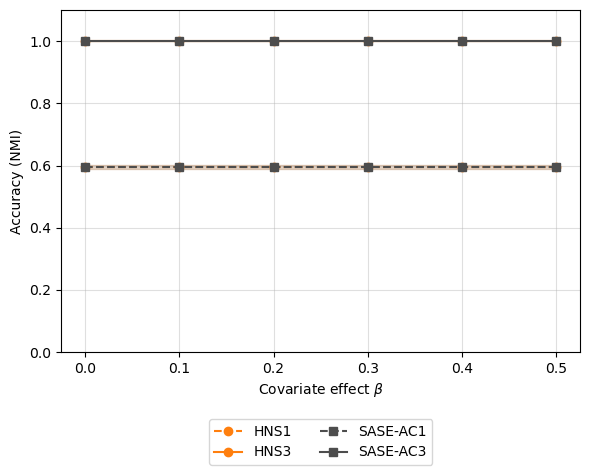

In [31]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.plot(beta_list, NMI_ACSBM1_beta, label='HNS1', marker='o', color='#ff7f0e', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_beta)-np.array(std_ACSBM1_beta), np.array(NMI_ACSBM1_beta)+np.array(std_ACSBM1_beta), alpha=0.15, color='#ff7f0e')
plt.plot(beta_list, NMI_ACSBM3_beta, label='HNS3', marker='o', color='#ff7f0e'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_beta)-np.array(std_ACSBM3_beta), np.array(NMI_ACSBM3_beta)+np.array(std_ACSBM3_beta), alpha=0.08, color='#ff7f0e')

plt.plot(beta_list, NMI_ACSBM1_AA_beta, label='SASE-AC1', marker='s', color='#4d4d4d', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_AA_beta)-np.array(std_ACSBM1_AA_beta), np.array(NMI_ACSBM1_AA_beta)+np.array(std_ACSBM1_AA_beta), alpha=0.15, color='#4d4d4d')
plt.plot(beta_list, NMI_ACSBM3_AA_beta, label='SASE-AC3', marker='s', color='#4d4d4d'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_AA_beta)-np.array(std_ACSBM3_AA_beta), np.array(NMI_ACSBM3_AA_beta)+np.array(std_ACSBM3_AA_beta), alpha=0.08, color='#4d4d4d')

plt.xlabel(r'Covariate effect $\beta$')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

### Directed

In [32]:
beta_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
iteration = 50
n = 400

B = 0.3 * np.eye(2) + 0.05

results = run_simulation(
    beta_list=beta_list,
    n=n,
    iteration=iteration,
    B=B,
    direction=True
)

(
    dense_dir_beta,

    NMI_ACSBM1_dir_beta, NMI_ACSBM3_dir_beta, NMI_ACSBM1_AA_dir_beta, NMI_ACSBM3_AA_dir_beta,

    std_ACSBM1_dir_beta, std_ACSBM3_dir_beta, std_ACSBM1_AA_dir_beta, std_ACSBM3_AA_dir_beta,

    time_ACSBM1_dir_beta, time_ACSBM3_dir_beta, time_ACSBM1_AA_dir_beta, time_ACSBM3_AA_dir_beta
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


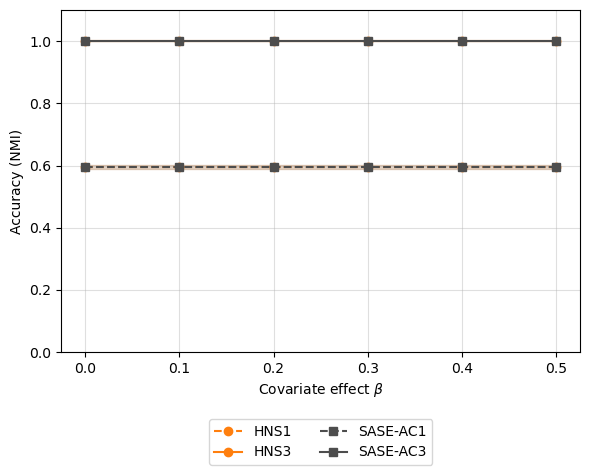

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.plot(beta_list, NMI_ACSBM1_dir_beta, label='HNS1', marker='o', color='#ff7f0e', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_dir_beta)-np.array(std_ACSBM1_dir_beta), np.array(NMI_ACSBM1_dir_beta)+np.array(std_ACSBM1_dir_beta), alpha=0.15, color='#ff7f0e')
plt.plot(beta_list, NMI_ACSBM3_dir_beta, label='HNS3', marker='o', color='#ff7f0e'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_dir_beta)-np.array(std_ACSBM3_dir_beta), np.array(NMI_ACSBM3_dir_beta)+np.array(std_ACSBM3_dir_beta), alpha=0.08, color='#ff7f0e')

plt.plot(beta_list, NMI_ACSBM1_AA_dir_beta, label='SASE-AC1', marker='s', color='#4d4d4d', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_AA_dir_beta)-np.array(std_ACSBM1_AA_dir_beta), np.array(NMI_ACSBM1_AA_dir_beta)+np.array(std_ACSBM1_AA_dir_beta), alpha=0.15, color='#4d4d4d')
plt.plot(beta_list, NMI_ACSBM3_AA_dir_beta, label='SASE-AC3', marker='s', color='#4d4d4d'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_AA_dir_beta)-np.array(std_ACSBM3_AA_dir_beta), np.array(NMI_ACSBM3_AA_dir_beta)+np.array(std_ACSBM3_AA_dir_beta), alpha=0.08, color='#4d4d4d')

plt.xlabel(r'Covariate effect $\beta$')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

## Non-assortative

### Undirected

In [34]:
beta_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
iteration = 50
n = 400

B = np.array([[0.2, 0.3], [0.3, 0.2]])

results = run_simulation(
    beta_list=beta_list,
    n=n,
    iteration=iteration,
    B=B
)

(
    dense_beta,

    NMI_ACSBM1_beta, NMI_ACSBM3_beta, NMI_ACSBM1_AA_beta, NMI_ACSBM3_AA_beta,

    std_ACSBM1_beta, std_ACSBM3_beta, std_ACSBM1_AA_beta, std_ACSBM3_AA_beta,

    time_ACSBM1_beta, time_ACSBM3_beta, time_ACSBM1_AA_beta, time_ACSBM3_AA_beta
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


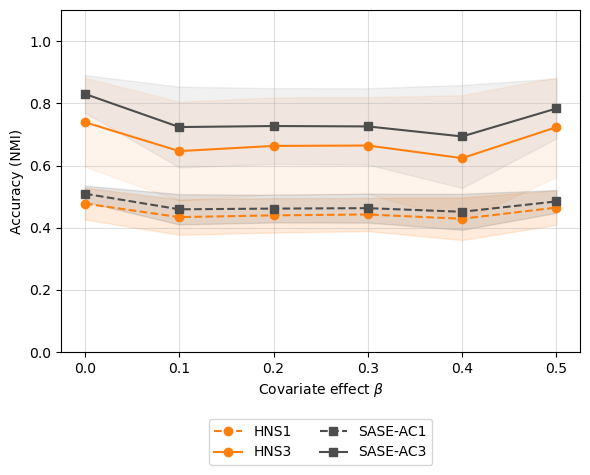

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.plot(beta_list, NMI_ACSBM1_beta, label='HNS1', marker='o', color='#ff7f0e', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_beta)-np.array(std_ACSBM1_beta), np.array(NMI_ACSBM1_beta)+np.array(std_ACSBM1_beta), alpha=0.15, color='#ff7f0e')
plt.plot(beta_list, NMI_ACSBM3_beta, label='HNS3', marker='o', color='#ff7f0e'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_beta)-np.array(std_ACSBM3_beta), np.array(NMI_ACSBM3_beta)+np.array(std_ACSBM3_beta), alpha=0.08, color='#ff7f0e')

plt.plot(beta_list, NMI_ACSBM1_AA_beta, label='SASE-AC1', marker='s', color='#4d4d4d', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_AA_beta)-np.array(std_ACSBM1_AA_beta), np.array(NMI_ACSBM1_AA_beta)+np.array(std_ACSBM1_AA_beta), alpha=0.15, color='#4d4d4d')
plt.plot(beta_list, NMI_ACSBM3_AA_beta, label='SASE-AC3', marker='s', color='#4d4d4d'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_AA_beta)-np.array(std_ACSBM3_AA_beta), np.array(NMI_ACSBM3_AA_beta)+np.array(std_ACSBM3_AA_beta), alpha=0.08, color='#4d4d4d')

plt.xlabel(r'Covariate effect $\beta$')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

### Directed

In [36]:
beta_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
iteration = 50
n = 400

B = np.array([[0.2, 0.3], [0.3, 0.2]])

results = run_simulation(
    beta_list=beta_list,
    n=n,
    iteration=iteration,
    B=B,
    direction=True
)

(
    dense_dir_beta,

    NMI_ACSBM1_dir_beta, NMI_ACSBM3_dir_beta, NMI_ACSBM1_AA_dir_beta, NMI_ACSBM3_AA_dir_beta,

    std_ACSBM1_dir_beta, std_ACSBM3_dir_beta, std_ACSBM1_AA_dir_beta, std_ACSBM3_AA_dir_beta,

    time_ACSBM1_dir_beta, time_ACSBM3_dir_beta, time_ACSBM1_AA_dir_beta, time_ACSBM3_AA_dir_beta
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


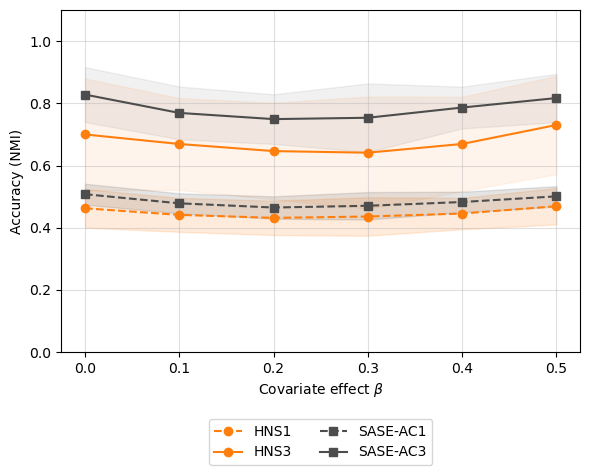

In [37]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.plot(beta_list, NMI_ACSBM1_dir_beta, label='HNS1', marker='o', color='#ff7f0e', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_dir_beta)-np.array(std_ACSBM1_dir_beta), np.array(NMI_ACSBM1_dir_beta)+np.array(std_ACSBM1_dir_beta), alpha=0.15, color='#ff7f0e')
plt.plot(beta_list, NMI_ACSBM3_dir_beta, label='HNS3', marker='o', color='#ff7f0e'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_dir_beta)-np.array(std_ACSBM3_dir_beta), np.array(NMI_ACSBM3_dir_beta)+np.array(std_ACSBM3_dir_beta), alpha=0.08, color='#ff7f0e')

plt.plot(beta_list, NMI_ACSBM1_AA_dir_beta, label='SASE-AC1', marker='s', color='#4d4d4d', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_AA_dir_beta)-np.array(std_ACSBM1_AA_dir_beta), np.array(NMI_ACSBM1_AA_dir_beta)+np.array(std_ACSBM1_AA_dir_beta), alpha=0.15, color='#4d4d4d')
plt.plot(beta_list, NMI_ACSBM3_AA_dir_beta, label='SASE-AC3', marker='s', color='#4d4d4d'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_AA_dir_beta)-np.array(std_ACSBM3_AA_dir_beta), np.array(NMI_ACSBM3_AA_dir_beta)+np.array(std_ACSBM3_AA_dir_beta), alpha=0.08, color='#4d4d4d')

plt.xlabel(r'Covariate effect $\beta$')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

## Core-periphery

### Undirected

In [38]:
beta_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
iteration = 50
n = 400

B = np.array([[0.5, 0.3], [0.3, 0.1]])

results = run_simulation(
    beta_list=beta_list,
    n=n,
    iteration=iteration,
    B=B
)

(
    dense_beta,

    NMI_ACSBM1_beta, NMI_ACSBM3_beta, NMI_ACSBM1_AA_beta, NMI_ACSBM3_AA_beta,

    std_ACSBM1_beta, std_ACSBM3_beta, std_ACSBM1_AA_beta, std_ACSBM3_AA_beta,

    time_ACSBM1_beta, time_ACSBM3_beta, time_ACSBM1_AA_beta, time_ACSBM3_AA_beta
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


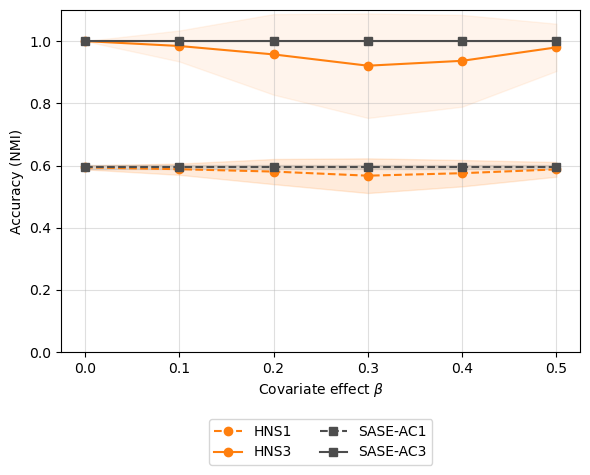

In [39]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.plot(beta_list, NMI_ACSBM1_beta, label='HNS1', marker='o', color='#ff7f0e', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_beta)-np.array(std_ACSBM1_beta), np.array(NMI_ACSBM1_beta)+np.array(std_ACSBM1_beta), alpha=0.15, color='#ff7f0e')
plt.plot(beta_list, NMI_ACSBM3_beta, label='HNS3', marker='o', color='#ff7f0e'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_beta)-np.array(std_ACSBM3_beta), np.array(NMI_ACSBM3_beta)+np.array(std_ACSBM3_beta), alpha=0.08, color='#ff7f0e')

plt.plot(beta_list, NMI_ACSBM1_AA_beta, label='SASE-AC1', marker='s', color='#4d4d4d', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_AA_beta)-np.array(std_ACSBM1_AA_beta), np.array(NMI_ACSBM1_AA_beta)+np.array(std_ACSBM1_AA_beta), alpha=0.15, color='#4d4d4d')
plt.plot(beta_list, NMI_ACSBM3_AA_beta, label='SASE-AC3', marker='s', color='#4d4d4d'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_AA_beta)-np.array(std_ACSBM3_AA_beta), np.array(NMI_ACSBM3_AA_beta)+np.array(std_ACSBM3_AA_beta), alpha=0.08, color='#4d4d4d')

plt.xlabel(r'Covariate effect $\beta$')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()

### Directed

In [40]:
beta_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
iteration = 50
n = 400

B = np.array([[0.5, 0.3], [0.3, 0.1]])

results = run_simulation(
    beta_list=beta_list,
    n=n,
    iteration=iteration,
    B=B,
    direction=True
)

(
    dense_dir_beta,

    NMI_ACSBM1_dir_beta, NMI_ACSBM3_dir_beta, NMI_ACSBM1_AA_dir_beta, NMI_ACSBM3_AA_dir_beta,

    std_ACSBM1_dir_beta, std_ACSBM3_dir_beta, std_ACSBM1_AA_dir_beta, std_ACSBM3_AA_dir_beta,

    time_ACSBM1_dir_beta, time_ACSBM3_dir_beta, time_ACSBM1_AA_dir_beta, time_ACSBM3_AA_dir_beta
) = results

Processing:   0%|          | 0/300 [00:00<?, ?it/s]

Processing completed.


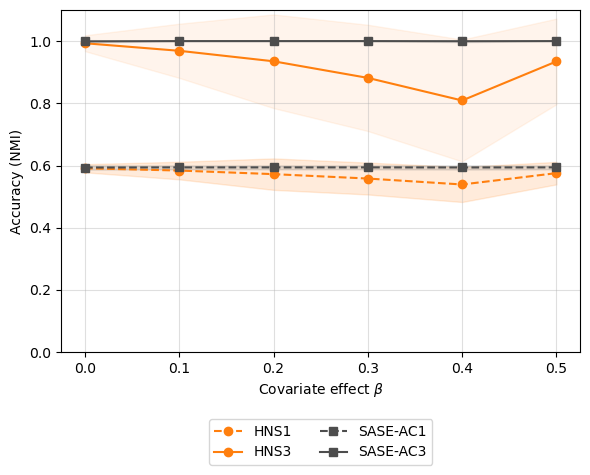

In [41]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.plot(beta_list, NMI_ACSBM1_dir_beta, label='HNS1', marker='o', color='#ff7f0e', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_dir_beta)-np.array(std_ACSBM1_dir_beta), np.array(NMI_ACSBM1_dir_beta)+np.array(std_ACSBM1_dir_beta), alpha=0.15, color='#ff7f0e')
plt.plot(beta_list, NMI_ACSBM3_dir_beta, label='HNS3', marker='o', color='#ff7f0e'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_dir_beta)-np.array(std_ACSBM3_dir_beta), np.array(NMI_ACSBM3_dir_beta)+np.array(std_ACSBM3_dir_beta), alpha=0.08, color='#ff7f0e')

plt.plot(beta_list, NMI_ACSBM1_AA_dir_beta, label='SASE-AC1', marker='s', color='#4d4d4d', linestyle='dashed'); plt.fill_between(beta_list, np.array(NMI_ACSBM1_AA_dir_beta)-np.array(std_ACSBM1_AA_dir_beta), np.array(NMI_ACSBM1_AA_dir_beta)+np.array(std_ACSBM1_AA_dir_beta), alpha=0.15, color='#4d4d4d')
plt.plot(beta_list, NMI_ACSBM3_AA_dir_beta, label='SASE-AC3', marker='s', color='#4d4d4d'); plt.fill_between(beta_list, np.array(NMI_ACSBM3_AA_dir_beta)-np.array(std_ACSBM3_AA_dir_beta), np.array(NMI_ACSBM3_AA_dir_beta)+np.array(std_ACSBM3_AA_dir_beta), alpha=0.08, color='#4d4d4d')

plt.xlabel(r'Covariate effect $\beta$')
plt.ylabel('Accuracy (NMI)')
plt.ylim(0, 1.1)
plt.grid(alpha=0.4)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.show()